In [354]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [355]:
# Load dataset
df = pd.read_csv('hourly.csv', parse_dates=["Date"], index_col="Date")
df.head()

,Unnamed: 0,Close,High,Low,Open,Volume
Date,,,,,,
2024-05-01 00:00:00+00:00,0,60205.000000,60763.929688,60028.417969,60612.921875,0
2024-05-01 01:00:00+00:00,1,60046.039062,60314.199219,59842.718750,60183.355469,252477440
2024-05-01 02:00:00+00:00,2,59856.140625,60091.367188,59546.796875,60066.855469,0
2024-05-01 03:00:00+00:00,3,60180.308594,60197.792969,59857.140625,59857.140625,162103296
2024-05-01 04:00:00+00:00,4,60200.472656,60255.406250,60141.253906,60169.007812,147656704


In [356]:
# Target column
df["Target_next_hour"] = df["Close"].pct_change().shift(-1)

In [357]:
df.columns

Index(['Unnamed: 0', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Target_next_hour'],
      dtype='str')

In [358]:
df_new = df.drop(columns=["Unnamed: 0"], errors="ignore")
df_new = df_new.reset_index()

In [359]:
df_new

,Date,Close,High,Low,Open,Volume,Target_next_hour
0,2024-05-01 00:00:00+00:00,60205.000000,60763.929688,60028.417969,60612.921875,0,-0.002640
1,2024-05-01 01:00:00+00:00,60046.039062,60314.199219,59842.718750,60183.355469,252477440,-0.003163
2,2024-05-01 02:00:00+00:00,59856.140625,60091.367188,59546.796875,60066.855469,0,0.005416
3,2024-05-01 03:00:00+00:00,60180.308594,60197.792969,59857.140625,59857.140625,162103296,0.000335
4,2024-05-01 04:00:00+00:00,60200.472656,60255.406250,60141.253906,60169.007812,147656704,-0.004320
...,...,...,...,...,...,...,...
17357,2026-04-30 17:00:00+00:00,76210.429688,76296.726562,76070.273438,76205.500000,0,0.001385
17358,2026-04-30 18:00:00+00:00,76316.000000,76442.031250,76165.523438,76222.367188,0,0.000856
17359,2026-04-30 19:00:00+00:00,76381.320312,76495.328125,76280.000000,76296.750000,0,0.001050
17360,2026-04-30 20:00:00+00:00,76461.500000,76537.726562,76291.968750,76383.796875,105375744,-0.000095


In [360]:
df_new.dtypes

Date                datetime64[us, UTC]
Close                           float64
High                            float64
Low                             float64
Open                            float64
Volume                            int64
Target_next_hour                float64
dtype: object

In [361]:
df_new['Hour'] = df_new['Date'].dt.hour

In [362]:
# Clean Date column
df_new["Date"] = pd.to_datetime(df_new["Date"]).dt.tz_localize(None)

# Keep only date part in Date column
df_new["Date"] = df_new["Date"].dt.normalize()


df_new["Date"] = df_new["Date"].dt.date

In [363]:
df_new.dtypes

Date                 object
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
Target_next_hour    float64
Hour                  int32
dtype: object

### Feature enginnering

In [364]:
#df_new["Date"] = pd.to_datetime(df_new["Date"])
#df1.index = df1.index.floor("D")
df1 = df_new.set_index("Date")
#df1.index.name = "Date"
#df1["Hour"] = df1.index.hour

df1.head()

,Close,High,Low,Open,Volume,Target_next_hour,Hour
Date,,,,,,,
2024-05-01,60205.000000,60763.929688,60028.417969,60612.921875,0,-0.002640,0
2024-05-01,60046.039062,60314.199219,59842.718750,60183.355469,252477440,-0.003163,1
2024-05-01,59856.140625,60091.367188,59546.796875,60066.855469,0,0.005416,2
2024-05-01,60180.308594,60197.792969,59857.140625,59857.140625,162103296,0.000335,3
2024-05-01,60200.472656,60255.406250,60141.253906,60169.007812,147656704,-0.004320,4


In [365]:
df1

,Close,High,Low,Open,Volume,Target_next_hour,Hour
Date,,,,,,,
2024-05-01,60205.000000,60763.929688,60028.417969,60612.921875,0,-0.002640,0
2024-05-01,60046.039062,60314.199219,59842.718750,60183.355469,252477440,-0.003163,1
2024-05-01,59856.140625,60091.367188,59546.796875,60066.855469,0,0.005416,2
2024-05-01,60180.308594,60197.792969,59857.140625,59857.140625,162103296,0.000335,3
2024-05-01,60200.472656,60255.406250,60141.253906,60169.007812,147656704,-0.004320,4
...,...,...,...,...,...,...,...
2026-04-30,76210.429688,76296.726562,76070.273438,76205.500000,0,0.001385,17
2026-04-30,76316.000000,76442.031250,76165.523438,76222.367188,0,0.000856,18
2026-04-30,76381.320312,76495.328125,76280.000000,76296.750000,0,0.001050,19


In [366]:
# convert to datetime
#df1.index = pd.to_datetime(df1.index)

# Remove Timezone
#df1.index = df1.index.tz_localize(None)

# keep only date
#df1.index = df1.index.normalize()


In [367]:
df1.columns = df1.columns.str.lower() # convert columns names to lower case
df1.columns

Index(['close', 'high', 'low', 'open', 'volume', 'target_next_hour', 'hour'], dtype='str')

In [368]:
df1.isnull().sum() # Check missing values

close               0
high                0
low                 0
open                0
volume              0
target_next_hour    1
hour                0
dtype: int64

In [369]:
df1.head()

,close,high,low,open,volume,target_next_hour,hour
Date,,,,,,,
2024-05-01,60205.000000,60763.929688,60028.417969,60612.921875,0,-0.002640,0
2024-05-01,60046.039062,60314.199219,59842.718750,60183.355469,252477440,-0.003163,1
2024-05-01,59856.140625,60091.367188,59546.796875,60066.855469,0,0.005416,2
2024-05-01,60180.308594,60197.792969,59857.140625,59857.140625,162103296,0.000335,3
2024-05-01,60200.472656,60255.406250,60141.253906,60169.007812,147656704,-0.004320,4


In [370]:
df1 = df1.dropna()

In [385]:
df1.isnull().sum()

close               0
high                0
low                 0
open                0
volume              0
target_next_hour    0
hour                0
dtype: int64

### Split the dataset

In [371]:
# Ensure index is proper datetime
df1.index = pd.to_datetime(df1.index)

# Define split date
split_date = pd.Timestamp("2026-04-28")

# Split
data_train = df1.loc[df1.index < split_date].copy()
data_test  = df1.loc[df1.index >= split_date].copy()

In [372]:
data_train.info()
print("Number of rows in data_train:", len(data_train))

<class 'pandas.DataFrame'>
DatetimeIndex: 17292 entries, 2024-05-01 to 2026-04-27
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   close             17292 non-null  float64
 1   high              17292 non-null  float64
 2   low               17292 non-null  float64
 3   open              17292 non-null  float64
 4   volume            17292 non-null  int64  
 5   target_next_hour  17292 non-null  float64
 6   hour              17292 non-null  int32  
dtypes: float64(5), int32(1), int64(1)
memory usage: 1013.2 KB
Number of rows in data_train: 17292


In [373]:
data_test.info()
print("Number of rows in data_test:", len(data_test))

<class 'pandas.DataFrame'>
DatetimeIndex: 69 entries, 2026-04-28 to 2026-04-30
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   close             69 non-null     float64
 1   high              69 non-null     float64
 2   low               69 non-null     float64
 3   open              69 non-null     float64
 4   volume            69 non-null     int64  
 5   target_next_hour  69 non-null     float64
 6   hour              69 non-null     int32  
dtypes: float64(5), int32(1), int64(1)
memory usage: 4.0 KB
Number of rows in data_test: 69


In [374]:
data_train.tail()

,close,high,low,open,volume,target_next_hour,hour
Date,,,,,,,
2026-04-27,76878.000000,76891.937500,76472.757812,76802.031250,182620160,0.001006,19
2026-04-27,76955.367188,77051.281250,76836.398438,76867.937500,305152000,-0.002318,20
2026-04-27,76777.000000,76980.539062,76777.000000,76945.921875,0,0.003570,21
2026-04-27,77051.109375,77076.468750,76735.000000,76805.296875,0,0.004066,22
2026-04-27,77364.406250,77444.398438,77007.757812,77029.140625,0,0.000225,23


In [375]:
data_test.head()

,close,high,low,open,volume,target_next_hour,hour
Date,,,,,,,
2026-04-28,77381.796875,77478.976562,77213.929688,77380.937500,0,-0.003921,0
2026-04-28,77078.359375,77399.687500,77043.609375,77368.320312,0,-0.002469,1
2026-04-28,76888.023438,77226.226562,76688.031250,77103.562500,0,-0.001023,2
2026-04-28,76809.351562,76895.882812,76682.171875,76876.039062,0,0.000993,3
2026-04-28,76885.601562,76952.843750,76697.531250,76808.000000,0,0.000057,4


In [376]:
data_test.shape, data_train.shape

((69, 7), (17292, 7))

In [377]:
## Create dependent and independent variables

# Independent variables (features)
X_train = data_train.drop(['target_next_hour'], axis=1)  

X_test = data_test.drop(['target_next_hour'], axis=1)

# Dependent variable (target)
y_train = data_train['target_next_hour']
y_test = data_test['target_next_hour']

In [378]:
X_train.shape, X_test.shape

((17292, 6), (69, 6))

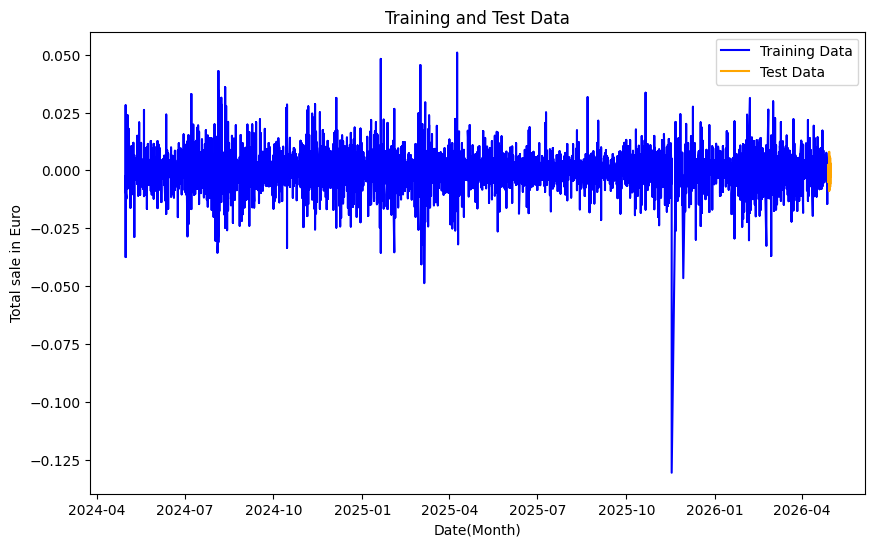

In [393]:
# Plotting
plt.figure(figsize=(10, 6))

# Plot training data
plt.plot(data_train.index, data_train['target_next_hour'], label='Training Data', color='blue')

# Plot test data
plt.plot(data_test.index, data_test['target_next_hour'], label='Test Data', color='orange')

plt.title('Training and Test Data')
plt.xlabel('Date(Month)')
plt.ylabel('Total sale in Euro')
plt.legend()

plt.show()

### XGBoost

In [380]:
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

In [387]:
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 4,
    "eta": 0.05,
    "seed": 42
}


In [388]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    evals=[(dtrain, "train"), (dtest, "test")]
)

[0]	train-rmse:0.00511	test-rmse:0.00319
[1]	train-rmse:0.00511	test-rmse:0.00319
[2]	train-rmse:0.00511	test-rmse:0.00319
[3]	train-rmse:0.00510	test-rmse:0.00319
[4]	train-rmse:0.00510	test-rmse:0.00319
[5]	train-rmse:0.00510	test-rmse:0.00319
[6]	train-rmse:0.00509	test-rmse:0.00319
[7]	train-rmse:0.00509	test-rmse:0.00319
[8]	train-rmse:0.00509	test-rmse:0.00319
[9]	train-rmse:0.00509	test-rmse:0.00319
[10]	train-rmse:0.00509	test-rmse:0.00319
[11]	train-rmse:0.00508	test-rmse:0.00319
[12]	train-rmse:0.00508	test-rmse:0.00319
[13]	train-rmse:0.00508	test-rmse:0.00319
[14]	train-rmse:0.00508	test-rmse:0.00319
[15]	train-rmse:0.00508	test-rmse:0.00319
[16]	train-rmse:0.00508	test-rmse:0.00319
[17]	train-rmse:0.00508	test-rmse:0.00319
[18]	train-rmse:0.00507	test-rmse:0.00319
[19]	train-rmse:0.00507	test-rmse:0.00319
[20]	train-rmse:0.00507	test-rmse:0.00319
[21]	train-rmse:0.00507	test-rmse:0.00319
[22]	train-rmse:0.00507	test-rmse:0.00319
[23]	train-rmse:0.00506	test-rmse:0.00319
[2

In [389]:
# Predict
y_pred = model.predict(dtest)

In [390]:
pred_df = pd.DataFrame({
    "Actual_Return": y_test,
    "Predicted_Return": y_pred
}, index=y_test.index)

pred_df.head()

,Actual_Return,Predicted_Return
Date,,
2026-04-28,-0.003921,0.000036
2026-04-28,-0.002469,0.000036
2026-04-28,-0.001023,0.000033
2026-04-28,0.000993,0.000033
2026-04-28,0.000057,0.000033


In [391]:
pred_df["Predicted_Direction"] = (pred_df["Predicted_Return"] > 0).astype(int)
pred_df["Actual_Direction"] = (pred_df["Actual_Return"] > 0).astype(int)

In [392]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    pred_df["Actual_Direction"],
    pred_df["Predicted_Direction"]
)

print("Direction Accuracy:", accuracy)

Direction Accuracy: 0.5072463768115942
